In [1]:
import os
import qsprpred
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("HIV/mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("HIV/mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("HIV/mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("HIV/mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("HIV/mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("HIV/mod_data/y3.1", index_col="QSPRID")


In [3]:
y1.Y.sum()/y1.Y.count()

0.04086892488954345

In [4]:
X1


,300,301,302,303,304,305,306,307,308,309,...,RDkit_fr_sulfonamd,RDkit_fr_sulfone,RDkit_fr_term_acetylene,RDkit_fr_tetrazole,RDkit_fr_thiazole,RDkit_fr_thiocyan,RDkit_fr_thiophene,RDkit_fr_unbrch_alkane,RDkit_fr_urea,RDkit_qed
QSPRID,,,,,,,,,,,,,,,,,,,,,
A2ARDataset_00000,0.856747,1.271848,0.477435,-0.832384,-0.801132,-0.988249,0.653618,0.065282,0.193137,0.049124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.434358
A2ARDataset_00001,0.452506,0.462552,-0.210664,-0.215571,0.515784,-0.152794,0.825898,-0.038565,0.136324,0.361213,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.581359
A2ARDataset_00002,-0.710739,0.348930,0.437538,-0.138845,0.188291,-0.577048,0.447970,0.189413,0.070475,0.084387,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.357615
A2ARDataset_00003,-0.730703,-0.058071,1.191474,-0.659712,0.153476,-0.437317,0.504877,-0.000563,-0.425432,-0.538998,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.538723
A2ARDataset_00004,-0.257824,1.094919,0.423548,-0.139947,-0.083240,-0.741900,0.448479,0.183446,0.290794,0.158408,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.790087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2ARDataset_21723,-0.130388,0.772013,0.152538,-0.037299,0.077947,-1.051099,0.573175,-0.003305,0.520750,0.302273,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.804191
A2ARDataset_21724,-0.029268,1.207125,0.066604,0.123513,0.018418,-1.239438,0.663889,-0.017742,0.653052,0.164743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.427745
A2ARDataset_21725,-0.081206,0.809170,-0.035853,0.158540,0.031100,-0.842095,0.343086,0.131871,0.488234,0.406605,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.450949


In [5]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,4712,4713,4714,4715,4716,4717,4718,4719,4720,4721
0,2.897648,2.029173,0.496849,-2.529852,-2.326563,-0.591198,0.657760,0.144160,0.072396,-0.600259,...,-0.201079,-0.124370,-0.053169,-0.047194,-0.166372,-0.021242,-0.135467,-0.154073,-0.172618,-0.278058
1,1.763969,-0.544379,-1.719227,-0.371087,1.951991,1.676018,1.261379,-0.145717,-0.107556,0.558700,...,-0.201079,-0.124370,-0.053169,-0.047194,-0.166372,-0.021242,-0.135467,-0.154073,-0.172618,0.372853
2,-1.498310,-0.905695,0.368358,-0.102557,0.887994,0.524698,-0.062772,0.490659,-0.316131,-0.469307,...,-0.201079,-0.124370,-0.053169,-0.047194,-0.166372,-0.021242,-0.135467,-0.154073,-0.172618,-0.617871
3,-1.554299,-2.199951,2.796470,-1.925523,0.774880,0.903893,0.136612,-0.039639,-1.886897,-2.784280,...,-0.201079,-0.124370,-0.053169,-0.047194,-0.166372,-0.021242,-0.135467,-0.154073,-0.172618,0.184064
4,-0.228126,1.466539,0.323304,-0.106414,0.005810,0.077331,-0.060989,0.474003,0.381722,-0.194425,...,-0.201079,-0.124370,-0.053169,-0.047194,-0.166372,-0.021242,-0.135467,-0.154073,-0.172618,1.297084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41675,0.593091,-0.955847,-0.511886,0.255226,1.358060,0.470943,-0.546898,-0.926536,-2.428366,-0.621560,...,-0.201079,0.325043,-0.053169,-0.047194,-0.166372,-0.021242,-0.135467,-0.154073,-0.172618,1.404119
41676,1.120334,1.889742,0.290116,0.064367,1.390609,1.394335,-1.242320,-2.582324,-0.780398,-2.107082,...,-0.201079,5.713078,-0.053169,-0.047194,-0.166372,-0.021242,-0.135467,-0.154073,-0.172618,1.119403
41677,-0.636438,-0.638158,0.620989,-1.653751,1.676015,0.305221,0.563134,0.262067,-0.302873,-0.143933,...,-0.201079,-0.124370,-0.053169,-0.047194,3.399524,-0.021242,-0.135467,0.208015,-0.172618,-0.253717
41678,1.184123,-0.575127,0.240252,-0.197383,-0.504212,0.590830,0.987876,0.138456,-0.294304,-0.001337,...,-0.201079,-0.124370,-0.053169,-0.047194,-0.166372,-0.021242,-0.135467,-0.117274,-0.172618,0.564307


In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X1)


PCA(n_components=0.95)

In [8]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1

In [9]:
n_components

2786

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

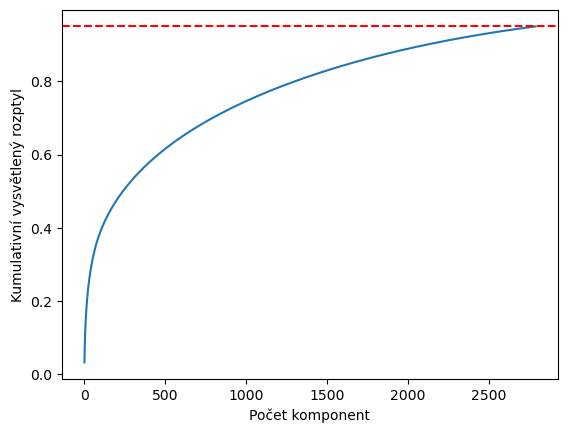

In [11]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [12]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [13]:
import optuna
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score

def objective(trial, X_train, y_train, X_val, y_val):
    """Definice cílové funkce pro Optunu"""

    # Návrh hyperparametrů pro dopřednou neuronovou síť
    params = {
        'dropout_frac': trial.suggest_float("dropout_frac", 0, 0.9),
        'patience': trial.suggest_int("patience", 10, 200),
        'tol': trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        'weight_decay': trial.suggest_float("weight_decay", 1e-6, 1e-1, log=True),
        'n_epochs': trial.suggest_int("n_epochs", 200, 2000),
        'batch_size': trial.suggest_categorical("batch_size", [64, 128, 256, 512, 1024]),
        'optimizer': trial.suggest_categorical("optimizer", ["AdamW", "RMSprop"]),
        'lr': trial.suggest_categorical("lr", [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]),
        'neuron_layers': trial.suggest_categorical("neuron_layers_size", ["[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]", "[4096, 1024, 256, 64, 8]", "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]", "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]", "[200]", "[2000]", "[2000, 1000]", "[2000, 1000, 500]", "[1000, 50]", "[4000, 2000]", "[4000, 2000, 1000, 500]", "[4000, 2000, 2000, 500]"])
    }

    neuron_layers_dict = {
        "[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[2048, 1024, 512, 256, 128, 64, 32, 16, 8]": [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 1024, 256, 64, 8]": [4096, 1024, 256, 64, 8],
        "[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]": [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
        "[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]": [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
        "[200]": [200],
        "[2000]": [2000],
        "[2000, 1000]": [2000, 1000],
        "[2000, 1000, 500]": [2000, 1000, 500],
        "[1000, 50]": [1000, 50],
        "[4000, 2000]": [4000, 2000],
        "[4000, 2000, 1000, 500]": [4000, 2000, 1000, 500],
        "[4000, 2000, 2000, 500]": [4000, 2000, 2000, 500]
    }
    params['neuron_layers'] = neuron_layers_dict[params['neuron_layers']]
    opt_func = optim.AdamW if params['optimizer'] == "AdamW" else optim.RMSprop

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Model
    model = STFullyConnected(
        n_dim=X_train.shape[1],
        n_class=1,
        device=device,
        act_fun=F.selu,
        dropout_frac=params['dropout_frac'],
        patience=params['patience'],
        tol=params['tol'],  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=params['weight_decay'],
        n_epochs=params['n_epochs'],
        neuron_layers=params['neuron_layers'],  # Použití neuron_layers_size
        batch_size=params['batch_size'],
        optimizer=opt_func,
        lr=params['lr'],
    )
    # Trénink a predikce
    model.fit(X_train, y_train, X_val, y_val)
    preds = model.predict(X_val)
    preds_bin = preds > 0.5

    # Metiky
    f1 = f1_score(y_val, preds_bin)
    acc = accuracy_score(y_val, preds_bin)
    mcc = matthews_corrcoef(y_val, preds_bin)

    # Můžeš logovat i do trialu
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    display(confusion_matrix(y_val, preds_bin))
    return mcc  # maximalizujeme MCC


In [ ]:
study = optuna.create_study(
    study_name="HIV_new_roberta_mol2vec_smote_pca_shuffle_cont",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=1000
)
print("Best MCC:", study.best_value)
print("Best parameters:", study.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study.best_trial.user_attrs["f1"])
print("Best ACC:", study.best_trial.user_attrs["acc"])

[I 2025-05-18 16:06:48,996] Using an existing study with name 'HIV_new_roberta_mol2vec_smote_pca_shuffle_cont' instead of creating a new one.


array([[8277,  308],
       [ 175,   91]])

[I 2025-05-18 16:14:47,167] Trial 59 finished with value: 0.2519942988802565 and parameters: {'dropout_frac': 0.26434223934231504, 'patience': 162, 'tol': 4.2521982317260406e-05, 'weight_decay': 8.769424562240835e-06, 'n_epochs': 1304, 'batch_size': 512, 'optimizer': 'RMSprop', 'lr': 0.0001, 'neuron_layers_size': '[200]'}. Best is trial 36 with value: 0.28351950720470376.


array([[8188,  397],
       [ 214,   52]])

[I 2025-05-18 16:35:56,634] Trial 60 finished with value: 0.11611733141623923 and parameters: {'dropout_frac': 0.8834753273049838, 'patience': 111, 'tol': 1.174836533002039e-05, 'weight_decay': 0.0002690105768631724, 'n_epochs': 1905, 'batch_size': 512, 'optimizer': 'AdamW', 'lr': 0.0001, 'neuron_layers_size': '[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]'}. Best is trial 36 with value: 0.28351950720470376.


...

[I 2025-05-19 15:16:16,967] Trial 153 finished with value: 0.27028646026309483 and parameters: {'dropout_frac': 0.3879086160513616, 'patience': 95, 'tol': 1.818602041536584e-05, 'weight_decay': 0.00016489537427064648, 'n_epochs': 880, 'batch_size': 1024, 'optimizer': 'AdamW', 'lr': 1e-06, 'neuron_layers_size': '[4096, 1024, 256, 64, 8]'}. Best is trial 79 with value: 0.2848981913922828.


array([[8332,  253],
       [ 172,   94]])

[I 2025-05-19 15:35:48,309] Trial 154 finished with value: 0.2849466729381782 and parameters: {'dropout_frac': 0.6835996259499566, 'patience': 159, 'tol': 2.5365106200130848e-05, 'weight_decay': 4.922799902662744e-06, 'n_epochs': 880, 'batch_size': 512, 'optimizer': 'AdamW', 'lr': 1e-06, 'neuron_layers_size': '[4096, 1024, 256, 64, 8]'}. Best is trial 154 with value: 0.2849466729381782.


array([[8278,  307],
       [ 169,   97]])

[I 2025-05-19 15:37:26,190] Trial 155 finished with value: 0.2690512626795809 and parameters: {'dropout_frac': 0.2330780754300174, 'patience': 41, 'tol': 0.00023959918755122537, 'weight_decay': 0.00010869964885199952, 'n_epochs': 1985, 'batch_size': 1024, 'optimizer': 'AdamW', 'lr': 0.0001, 'neuron_layers_size': '[1000, 50]'}. Best is trial 154 with value: 0.2849466729381782.


In [ ]:
study_4.best_params

In [20]:

model = STFullyConnected(
        n_dim=X1.shape[1],
        n_class=1,
        device="cuda",
        act_fun=F.selu,
        dropout_frac=0.5864556491418137,
        patience=120,
        tol=0.00014812537413413796,  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=0.00024149981221142447,
        n_epochs=572,
        neuron_layers= [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],  # Použití neuron_layers_size
        batch_size=64,
        optimizer=optim.AdamW,
        lr=1e-05,
    seed = 69,
    print_outputs= 2
    )
model.fit(X1,y1,X2,y2) #0.6084853456048988

Epoch 1 | Train Loss: 0.6713 | Valid Loss: 0.7669 | MCC: 0.0000
Epoch 2 | Train Loss: 0.6741 | Valid Loss: 0.7656 | MCC: 0.0000
Epoch 3 | Train Loss: 0.7849 | Valid Loss: 0.7646 | MCC: 0.0000
Epoch 4 | Train Loss: 0.7204 | Valid Loss: 0.7635 | MCC: 0.0000
Epoch 5 | Train Loss: 0.8003 | Valid Loss: 0.7626 | MCC: 0.0000
Epoch 6 | Train Loss: 0.7634 | Valid Loss: 0.7616 | MCC: 0.0000
Epoch 7 | Train Loss: 0.8002 | Valid Loss: 0.7604 | MCC: 0.0000
Epoch 8 | Train Loss: 0.7472 | Valid Loss: 0.7589 | MCC: 0.0000
Epoch 9 | Train Loss: 0.6923 | Valid Loss: 0.7576 | MCC: 0.0000
Epoch 10 | Train Loss: 0.7349 | Valid Loss: 0.7564 | MCC: 0.0000
Epoch 11 | Train Loss: 0.6873 | Valid Loss: 0.7550 | MCC: 0.0000
Epoch 12 | Train Loss: 0.7530 | Valid Loss: 0.7535 | MCC: 0.0000
Epoch 13 | Train Loss: 0.7333 | Valid Loss: 0.7520 | MCC: 0.0000
Epoch 14 | Train Loss: 0.7473 | Valid Loss: 0.7505 | MCC: 0.0000
Epoch 15 | Train Loss: 0.7367 | Valid Loss: 0.7493 | MCC: 0.0000
Epoch 16 | Train Loss: 0.6822 | Va

(STFullyConnected(
   (layers): ModuleList(
     (0): Linear(in_features=278, out_features=4096, bias=True)
     (1): Linear(in_features=4096, out_features=3072, bias=True)
     (2): Linear(in_features=3072, out_features=2048, bias=True)
     (3): Linear(in_features=2048, out_features=1536, bias=True)
     (4): Linear(in_features=1536, out_features=1024, bias=True)
     (5): Linear(in_features=1024, out_features=768, bias=True)
     (6): Linear(in_features=768, out_features=512, bias=True)
     (7): Linear(in_features=512, out_features=256, bias=True)
     (8): Linear(in_features=256, out_features=128, bias=True)
     (9): Linear(in_features=128, out_features=64, bias=True)
     (10): Linear(in_features=64, out_features=32, bias=True)
     (11): Linear(in_features=32, out_features=16, bias=True)
     (12): Linear(in_features=16, out_features=8, bias=True)
     (13): Linear(in_features=8, out_features=1, bias=True)
   )
   (dropout): Dropout(p=0.5864556491418137, inplace=False)
   (crit

In [21]:
preds = model.predict(X2)
preds_bin = preds > 0.5

mcc = matthews_corrcoef(y2, preds_bin)
display(mcc)

0.41860617364970404

In [22]:
preds = model.predict(X3)
preds_bin = preds > 0.5

    # Metiky
f1 = f1_score(y3, preds_bin)
acc = accuracy_score(y3, preds_bin)
mcc = matthews_corrcoef(y3, preds_bin)

In [23]:
display(mcc) # 0.17324800323685596

0.30497289541289485

In [25]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/setuptools/_vendor', '/tmp/tmp5tfx0zz9']
/home/ubuntu/Bakalarka/QSPRpred
lol
